In [ ]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import copy
import sys

!rm -r /kaggle/working/Architectural-Biases-in-Time-Series-Anomaly-Detection
!git clone https://github.com/KirillVishnyakov/Architectural-Biases-in-Time-Series-Anomaly-Detection

rm: cannot remove '/kaggle/working/Architectural-Biases-in-Time-Series-Anomaly-Detection': No such file or directory
Cloning into 'Architectural-Biases-in-Time-Series-Anomaly-Detection'...
remote: Enumerating objects: 160, done.
remote: Counting objects: 100% (160/160), done.
remote: Compressing objects: 100% (118/118), done.
remote: Total 160 (delta 87), reused 110 (delta 40), pack-reused 0 (from 0)
Receiving objects: 100% (160/160), 1.69 MiB | 7.75 MiB/s, done.
Resolving deltas: 100% (87/87), done.


### Import necessary functions/modules from git repository

In [ ]:
sys.path.append("/kaggle/working/Architectural-Biases-in-Time-Series-Anomaly-Detection")
from dataset import LSTM_Dataset
from lstm import short_window_LSTM
from utils import load_config
from evaluate import evaluate_lstm_scores

if torch.cuda.is_available():
    device = torch.device("cuda")
base_config = load_config("/kaggle/working/Architectural-Biases-in-Time-Series-Anomaly-Detection/config.yaml")

In [ ]:
final_config = copy.deepcopy(base_config)
final_config["training"]["lr"] = 0.001
final_config["training"]["batch_size"] = 64
final_config["training"]["num_epochs"] = 100
final_config["model"]["hidden_size"] = 128

final_config["experiment_name"] = f"lr{0.001}_bs{64}_hs{128}"
final_short_window_lstm = short_window_LSTM(**final_config["model"]).to(device)

In [4]:
final_short_window_lstm.load_state_dict(
    torch.load("/kaggle/working/Architectural-Biases-in-Time-Series-Anomaly-Detection/saved_model_weights/LSTM_short_window_weights.pth", 
               weights_only=True))

<All keys matched successfully>

### Tuning the treshold on separate validation data that contains anomalies

In [5]:
forecasting_validation_dataset = LSTM_Dataset(device, 5, start = 1000000, end = 3500000, train = False)
forecasting_testing_dataset = LSTM_Dataset(device, 5, start = 3500000, end = 5000000, train = False)

In [7]:
scores, labels, categories = evaluate_lstm_scores(final_short_window_lstm, forecasting_validation_dataset)

### Percentile Method to determine the threshold. Sweep over multiple anomaly smoothing window sizes.

In [117]:
# Assuming 3.8% contamination rate from the dataset description
threshold = np.percentile(scores, 100 - 3.8) 
window_grid = [180, 200, 220, 240, 260, 280, 300]
for window in window_grid:
    current_score = scores
    if window > 1:
        current_score = np.convolve(scores, np.ones(window) / window, mode='same')
    TP = np.sum((current_score > threshold) & (labels == 1))
    FP = np.sum((current_score > threshold) & (labels == 0))
    recall = TP/forecasting_validation_dataset.total_anomalies
    precision = TP/(TP + FP)
    F1 = 2 * (precision * recall)/(precision + recall)
    print(f"| window: {window} | recall {recall:.2f}, precision {precision:.2f}, F1 {F1:.4f}")


| window: 180 | recall 0.19, precision 0.96, F1 0.3128
| window: 200 | recall 0.19, precision 0.96, F1 0.3141
| window: 220 | recall 0.19, precision 0.96, F1 0.3160
| window: 240 | recall 0.19, precision 0.95, F1 0.3175
| window: 260 | recall 0.19, precision 0.95, F1 0.3197
| window: 280 | recall 0.19, precision 0.95, F1 0.3212
| window: 300 | recall 0.19, precision 0.95, F1 0.3204


#### Choosing window_size = 280

### Brief interpretation of the scoring and anomaly smoothing.

In [105]:
df = pd.read_csv("/kaggle/input/datasets/kirillvishnyakov/cats-dataset/data.csv")
df_validate = df[1000000: 3500000]
df_test = df[3500000:]

In [123]:
def visualize_scores(start, end, window = 1, title = ""):

    scores_plot = np.array(scores)[start: end]
    labels_plot = np.array(labels)[start: end]
    
    # plot
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
    
    ax1.plot(scores_plot, linewidth=0.5)
    ax1.axhline(y=np.percentile(scores, 100 - 3.8) , color='r', linestyle='--', label=f'threshold={np.percentile(scores, 100 - 3.8):.4f}')
    ax1.set_ylabel('anomaly score')
    ax1.legend()

    ax2.plot(np.convolve(scores_plot, np.ones(window) / window, mode='same'), linewidth=0.5)
    ax2.axhline(y=np.percentile(scores, 100 - 3.8) , color='b', linestyle='--', label=f'threshold={np.percentile(scores, 100 - 3.8):.4f}')
    ax2.set_ylabel('anomaly smoothed score')
    ax2.legend()
    
    ax3.plot(labels_plot, linewidth=0.5, color='orange')
    ax3.set_ylabel('anomaly label')
    ax3.set_xlabel('timestep')
    ticks = ax3.get_xticks()
    ax3.set_xticklabels([int(tick + start) for tick in ticks])
    plt.title(title)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_55/1813461231.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels([int(tick + start) for tick in ticks])


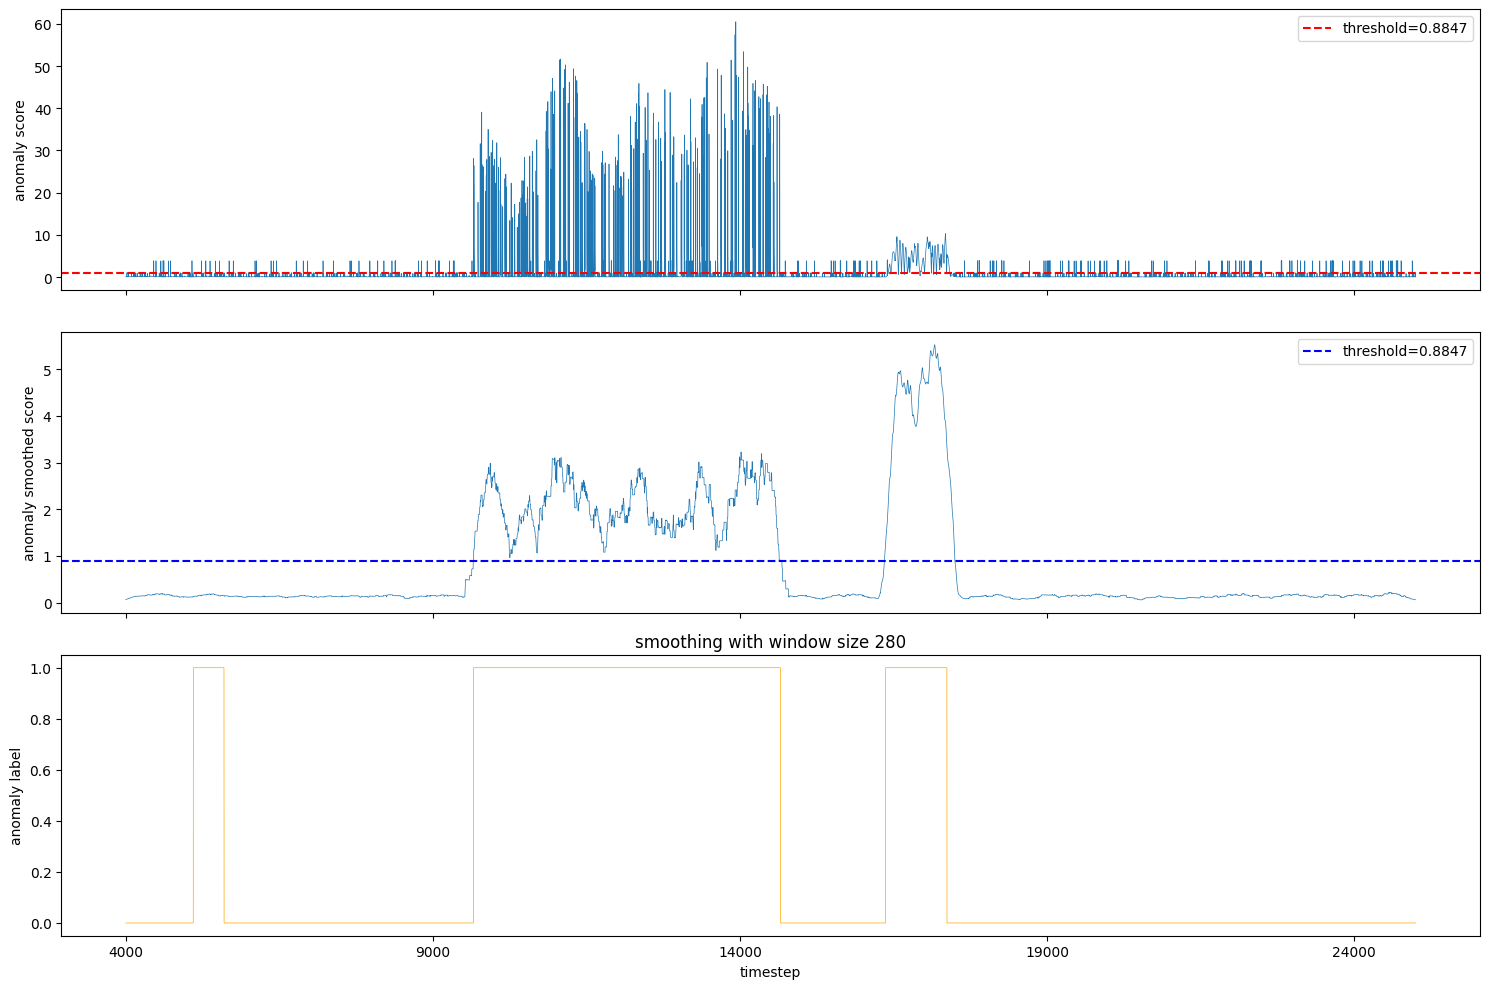

In [124]:
visualize_scores(4000, 25000, 280, title = "smoothing with window size 280")

In [84]:
print(df_validate[4000:8000]["category"].value_counts())
print(df_validate[9000:15000]["category"].value_counts())
print(df_validate[15000:19000]["category"].value_counts())

category
0.0     3500
12.0     500
Name: count, dtype: int64
category
1.0    5000
0.0    1000
Name: count, dtype: int64
category
0.0    3000
8.0    1000
Name: count, dtype: int64


#### On this section, the model detects anomaly types 1 and 8 well but completely misses type 12, with false positives scattered throughout. Smoothing the residuals helps a lot with precision.

### Now evaluating metrics on the testing dataset

In [109]:
test_scores, test_labels, test_categories = evaluate_lstm_scores(final_short_window_lstm, forecasting_testing_dataset)

### Global F1

In [241]:
threshold, window = np.percentile(scores, 100 - 3.8), 280
current_test_score = np.convolve(test_scores, np.ones(window) / window, mode='same')
TP = np.sum((current_test_score > threshold) & (test_labels == 1))
FP = np.sum((current_test_score > threshold) & (test_labels == 0))
recall = TP/forecasting_testing_dataset.total_anomalies
precision = TP/(TP + FP)
F1 = 2 * (precision * recall)/(precision + recall)
print(f"| evaluation_threshold: {threshold:.4f} | window: {window} | recall {recall:.4f}, precision {precision:.4f}, F1 {F1:.4f}")

| evaluation_threshold: 0.8847 | window: 280 | recall 0.3090, precision 0.9328, F1 0.4643


### Per Anomaly category metric evaluation

In [242]:
window_grid = [1, 5, 100, 280]
series = []
for window in window_grid:
    if window > 1:
        current_test_score = np.convolve(test_scores, np.ones(window)/window, mode='same')
    else:
        current_test_score = test_scores
    cat_dict = {}
    normal_mask = test_categories == 0
    FPR = np.sum((current_test_score[normal_mask] > threshold)) / np.sum(normal_mask)
    cat_dict["FPR (0.0)"] = np.round(FPR, decimals=2).item()

    for cat in np.unique(test_categories):
        if cat == 0.0:
            continue
        cat_mask = test_categories == cat
        cat_TP = np.sum((current_test_score[cat_mask] > threshold))
        recall = cat_TP / np.sum(cat_mask)
        cat_dict[f"recall ({cat})"] = np.round(recall, decimals=2).item()

    series.append(pd.Series(cat_dict, name=f"thresh={threshold:.2f}, w={window}"))

f_concat = pd.concat(series, axis=1)

In [243]:
f_concat

,"thresh=0.88, w=1","thresh=0.88, w=5","thresh=0.88, w=100","thresh=0.88, w=280"
FPR (0.0),0.03,0.04,0.00,0.00
recall (1.0),0.20,0.28,0.48,0.49
recall (2.0),0.49,0.50,0.51,0.63
recall (3.0),0.49,0.50,0.51,0.52
recall (4.0),0.23,0.24,0.21,0.23
recall (5.0),0.10,0.10,0.08,0.09
recall (6.0),0.04,0.06,0.00,0.00
recall (7.0),0.04,0.05,0.00,0.00
recall (8.0),0.26,0.28,0.33,0.30
recall (9.0),0.37,0.38,0.33,0.31


#### Anonaly types 1, 2, and 3 benefit a lot from larger windows. False positives drop significantly with smoothing. <br>The model is better at detecting anomalies 2 > 3 > 1 > 9 > 8 > 4 > 5 > ...


### Comparing with statistical baseline

In [172]:
import numpy as np
from sklearn.metrics import f1_score
import torch

series = np.array([torch.linalg.norm(forecasting_testing_dataset[idx][1]).item() for idx in range(len(forecasting_testing_dataset))])
y_true = np.array([forecasting_testing_dataset[idx][2] for idx in range(len(forecasting_testing_dataset))])

threshold = series.mean() + 3 * series.std()
baseline_preds = (series > threshold).astype(int)

f1_baseline = f1_score(y_true, baseline_preds)
print("Simple global mean+3*std baseline F1:", f1_baseline)

Simple global mean+3*std baseline F1: 0.2891641386587369


### 